# Datacamp 2023
## TP Kastor

Cette librairie python propose une **automatisation de la chaine de production de scores pour des données temporelles**.
Elle permet de dérouler la chaine de production de scores de bout en bout.
Les traitements Khiops sont automatisés via pykhiops, allant de la production du modèle à la restitution de scores par période predéfinies ainsi qu’à leur évaluation.
Les modules définis sont les suivants :


- **generate_train_test** : création du dataset
    - sélection des cibles comprises dans un intervalle temporel à spécifier
    - tirage aléatoire d’une date pour les non cibles et les cibles hors intervalle (tirage parmi les dates de logs si l’intervalle correspond, parmi les dates de cible sinon)
    - constitution des deux datasets train et test


- **fit** : modélisation sur période fixe et/ou sur période mobile


- **predict** : déploiement sur période fixe et/ou sur période mobile
    - sur une période fixe définie (par exemple 1 mois en marketing)
    - sur une période mobile : les traitements sont effectués sur une période mobile définie en paramètre (par exemple 1, 7 ou 15 jours en marketing)


- **evaluate** : deux métriques d'évaluation
    - précision
    - rappel
    
- **plot** : tracé, par décile, des courbes précision et rappel

In [1]:
import os
os.chdir('..')

In [2]:
pwd

'D:\\Donnees\\OF\\ScoringFutur\\kastor_2024'

In [3]:
import sys
import datetime

DataPath = os.path.join(".")
DataLibPath = os.path.join(DataPath,"kastor")
if not DataLibPath in sys.path:
    sys.path.append(DataLibPath)

import kastor.kastor as kt

<div style="background-color:MediumSeaGreen; text-align:center; vertical-align: middle; padding:40px 0; color:white">

## Paramètres

<img src="images\data_tables.jpg">

In [4]:
# répertoire de travail
repertoire_donnees = os.path.join(DataPath,"notebook","data","synth1")

# Séparateur
sep = '\t'

# dictionnaire Khiops
dictionary = os.path.join(repertoire_donnees,"sample2_synthetic_dm_ids.kdic")

# data_table : définition des données et de leurs liens key et datetime
data_tables = {
    # nom de la table principale comportant la cible horodatée
   "main_table": {
        "name_main_table": "TablePrincipale",
        "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_ids.csv"),
        "key": 'ID'
        },
   # datamarts
   "entities": {
        "DataMart1": [{  # liste de fichiers datamarts caractérisés par leur datetime
            "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_DM1_07.csv"),
            "key": 'ID',
            "datetime": datetime.date(2019, 9, 1) # correspond à la date mise à disposition des donnees,
            # ce sont donc les donnees antérieures
            # a exprimer dans la meme unite que target_parameters["datetime"]
            },
            {
            "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_DM1_08.csv"),
            "key": 'ID',
            "datetime": datetime.date(2019, 10, 1)
            },
            {
            "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_DM1_09.csv"),
            "key": 'ID',
            "datetime": datetime.date(2019, 11, 1)
            }],

        },
   # tables de logs
   "tables": {
        "LOGS": {
            "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_log.csv"),
            "key": 'ID',
            "datetime": 'EVENT_DATE'
            },
        }
    }


<img src="images\target_parameters.jpg">

In [5]:
# Paramètres temporels de l'étude
temporal_parameters = {
    # "input_data_duration", "model_gap" et "target_duration" sont à exprimer dans la même unité que *period_unit*
    "period_unit" : "days",     # time unit for fit and for predict : "days", "hours" or "minutes"
    "input_data_duration" : 60, # durée de prise en compte des logs (Tx)
    "model_gap" : 7,            # gap du modèle (correspond au gap métier) (tau)
    # "target_duration" : 7,      # profondeur d observation de la cible (Ty)
    "start_date": datetime.date(2019, 10, 1),          # optionnel, 1er jour du fichier target si non renseigné
    #"end_date": datetime.date(2019, 10, 30),           # optionnel, period_nb si non renseigné
    "period_nb": 15   # durée de la période de scores # optionnel, défaut 1, si spécifié end_date est ignoré
    }

if temporal_parameters["period_unit"] not in ["days", "hours", "minutes"]:
    raise ValueError("frequence de deploiement à renseigner parmi : days, hours, minutes")
    
# répertoire des analyses, par défaut fixe et mobile, possibilité de suffixer
#path_suffix = str(temporal_parameters['target_duration'])   # optionnel

In [6]:
# Paramètres liés à la cible (dans la table principale)
target_parameters = {
    "datetime": 'EVENT_DATE',
    "target": 'TARGET',
    "main_target_modality": 1,  # optionnel
    "default_target_modality": 0  # optionnel
    }

<div style="background-color:LightGreen; text-align:center; vertical-align: middle; padding:40px 0;">

## Création dataset

<div style="background-color:LightGreen; padding:10px 0;">
    
### *train / test*
    
- sélection des cibles comprises dans l'intervalle spécifié
   
- tirage aléatoire d'une date pour les non cibles (parmi les dates de logs si l'intervalle correspond, parmi les dates de cible sinon)
   
- constitution des deux datasets train et test

In [7]:
generate_dataset_traintest = kt.GenerateDataset(
    dictionary, 
    data_tables, 
    target_parameters, 
    temporal_parameters,
)

generate_dataset_traintest.mobile=False
generate_dataset_traintest.sep = sep

(
    mydataset_train, 
    mydataset_test,
)= generate_dataset_traintest.train_test_split()

.\notebook\data\synth1\sample2_synthetic_ids.csv --> 12017 lignes

          ID  EVENT_DATE
TARGET                  
0       7046           0
1       4971        4971


timestamp min: 2019-09-02 00:00:00
timestamp max: 2019-11-30 00:00:00


.\notebook\data\synth1\sample2_synthetic_log.csv --> 798379 lignes

timestamp min: 2019-05-20 00:12:10
timestamp max: 2019-11-15 23:58:37

Nombre de cibles avec modalite 1 comprises entre le 2019-10-01 00:00:00 et le 2019-10-15 00:00:00 : 865

Duree d execution de l'affectation d une date aleatoire aux cibles 0 : 4s

fichier train : 7124 ids, 609 cibles avec modalité 1
écriture du fichier train : .\notebook\data\synth1\sample2_synthetic_ids_train.csv

fichier test : 3053 ids, 256 cibles avec modalité 1
écriture du fichier test : .\notebook\data\synth1\sample2_synthetic_ids_test.csv


In [8]:
temporal_parameters_back = {
    # "input_data_duration", "model_gap" et "target_duration" sont à exprimer dans la même unité que *period_unit*
    "period_unit" : "days",     # time unit for fit and for predict : "days", "hours" or "minutes"
    "input_data_duration" : 60, # durée de prise en compte des logs (Tx)
    "model_gap" : 7,            # gap du modèle (correspond au gap métier) (tau)
    #"target_duration" : 7,      # profondeur d observation de la cible (Ty)
    "start_date": datetime.date(2019, 11, 1),          # optionnel
    #"end_date": datetime.date(2019, 11, 15),           # optionnel, period_nb si non renseigné
    "period_nb": 15   # durée de la période de scores # optionnel, défaut 1, si spécifié end_date est ignoré
    }

In [9]:
generate_dataset_back = kt.GenerateDataset(
    dictionary, 
    data_tables, 
    target_parameters, 
    temporal_parameters_back,
)

generate_dataset_back.mobile=False
generate_dataset_back.sep = sep

mydataset_back = generate_dataset_back.generate_dataset()

.\notebook\data\synth1\sample2_synthetic_ids.csv --> 12017 lignes

          ID  EVENT_DATE
TARGET                  
0       7046           0
1       4971        4971


timestamp min: 2019-09-02 00:00:00
timestamp max: 2019-11-30 00:00:00


.\notebook\data\synth1\sample2_synthetic_log.csv --> 798379 lignes

timestamp min: 2019-05-20 00:12:10
timestamp max: 2019-11-15 23:58:37

Nombre de cibles avec modalite 1 comprises entre le 2019-11-01 00:00:00 et le 2019-11-16 00:00:00 : 825

Duree d execution de l'affectation d une date aleatoire aux cibles 0 : 1s

fichier backtesting : 8465 ids, 825 cibles avec modalité 1
écriture du fichier backtesting : .\notebook\data\synth1\sample2_synthetic_ids_backtesting.csv

durée d'exécution : 0:00:12.376133


<div style="background-color:LightGreen; padding:10px 0;">
    
### *déploiement*
    
- tirage aléatoire d'une date parmi les dates de logs
   
- constitution du dataset depl

In [11]:
# dictionnaire Khiops
dictionary_depl = os.path.join(repertoire_donnees,"sample2_synthetic_dm_ids_depl.kdic")

data_tables_depl = {
    # nom de la table principale comportant la cible horodatée
   "main_table": {
        "name_main_table": "TablePrincipale",
        "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_ids_depl_sans_target.csv"),
        "key": 'ID'
        },
   # datamarts
   "entities": {
        "DataMart1": [{  # liste de fichiers datamarts caractérisés par leur datetime
            "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_DM1_07.csv"),
            "key": 'ID',
            "datetime": datetime.date(2019, 9, 1) # correspond à la date mise à disposition des donnees,
            # ce sont donc les donnees antérieures
            # a exprimer dans la meme unite que target_parameters["datetime"]
            },
            {
            "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_DM1_08.csv"),
            "key": 'ID',
            "datetime": datetime.date(2019, 10, 1)
            },
            {
            "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_DM1_09.csv"),
            "key": 'ID',
            "datetime": datetime.date(2019, 11, 1)
            }],

        },
   # tables de logs
   "tables": {
        "LOGS": {
            "file_name": os.path.join(repertoire_donnees,"sample2_synthetic_log.csv"),
            "key": 'ID',
            "datetime": 'EVENT_DATE'
            }
        }
    }


In [12]:
temporal_parameters_depl = {
    # "input_data_duration", "model_gap" et "target_duration" sont à exprimer dans la même unité que *period_unit*
    "period_unit" : "days",     # time unit for fit and for predict : "days", "hours" or "minutes"
    "input_data_duration" : 60, # durée de prise en compte des logs (Tx)
    "model_gap" : 7,            # gap du modèle (correspond au gap métier) (tau)
    #"target_duration" : 7,      # profondeur d observation de la cible (Ty)
    "start_date": datetime.date(2019, 11, 1),          # optionnel
    #"end_date": datetime.date(2019, 10, 30),           # optionnel, period_nb si non renseigné
    "period_nb": 1   # durée de la période de scores # optionnel, défaut 1, si spécifié end_date est ignoré
    }

In [13]:
generate_dataset_depl = kt.GenerateDataset(
    dictionary_depl, 
    data_tables_depl, 
    target_parameters, 
    temporal_parameters_depl,
)

generate_dataset_depl.mobile=False
generate_dataset_depl.sep = sep

mydataset_depl = generate_dataset_depl.generate_dataset()

.\notebook\data\synth1\sample2_synthetic_ids_depl_sans_target.csv --> 3331 lignes


fichier depl : 3331 ids 
écriture du fichier depl : .\notebook\data\synth1\sample2_synthetic_ids_depl_sans_target_depl.csv

durée d'exécution : 0:00:03.824708


<div style="background-color:PaleGoldenrod; text-align:center; vertical-align: middle; padding:40px 0;">
    
## Période fixe

<div style="background-color:PaleGoldenrod; padding:10px 0;">
    
### Modélisation
    
période fixe

In [14]:
mymodel_fixe = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters,
)

mymodel_fixe.mobile=False
mymodel_fixe.sep = sep
mymodel_fixe.result_suffix = 'test'

mymodel_fixe.fit(mydataset_train)

fichier train : .\notebook\data\synth1\sample2_synthetic_ids_train.csv
dictionnaire :.\notebook\data\synth1\sample2_synthetic_dm_ids.kdic
durée d'exécution : 0:00:57.776131


<div style="background-color:PaleGoldenrod; padding:10px 0;">

### *train / test* : déploiement
    
période fixe
    
test sur les mêmes dates que le train

In [15]:
mymodel_fixe = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters,
)

mymodel_fixe.mobile=False
mymodel_fixe.sep = sep
mymodel_fixe.result_suffix = 'test'

(
    score_by_period_unit_traintest_fixe, 
    target_by_period_unit_traintest_fixe,
) = mymodel_fixe.predict(mydataset_test)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_test.csv
répertoire : .\notebook\data\synth1\fixe\TransferDatabase_test --> nombre de déploiements : 2
durée d'exécution : 0:00:08.693027


<div style="background-color:PaleGoldenrod; padding:10px 0;">

### *train / test* : évaluation 
     
   période fixe
    
   constitution de la table des scores et cibles journaliers (table pivot)
   
   calcul des indicateurs : precision et rappel

In [16]:
myeval_traintest_fixe = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters,
)

myeval_traintest_fixe.mobile=False
myeval_traintest_fixe.sep = sep
myeval_traintest_fixe.result_suffix = 'test'

evaluation_traintest_fixe = myeval_traintest_fixe.evaluate(
    score_by_period_unit_traintest_fixe, 
    target_by_period_unit_traintest_fixe,
)

Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\fixe\eval_reactif_test.xls
Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\fixe\eval_reactif_test.json


<div style="background-color:PaleGoldenrod; padding:10px 0;">

### *train / test* : représentations graphiques 
    
   période fixe
    
   courbes par top scores des deux métriques : précision et rappel

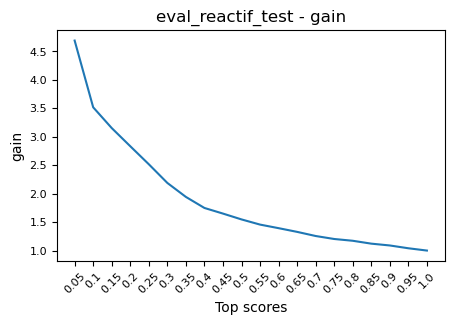

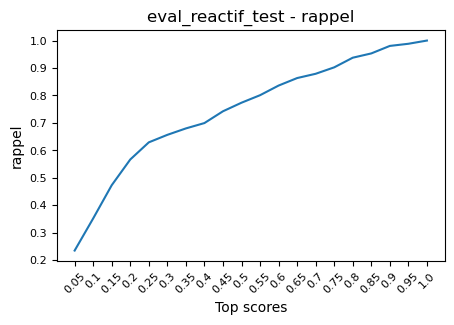

In [17]:
myeval_traintest_fixe = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters,
)

myeval_traintest_fixe.mobile=False
myeval_traintest_fixe.sep = sep
myeval_traintest_fixe.result_suffix = 'test'

myeval_traintest_fixe.plot(evaluation_traintest_fixe)

<div style="background-color:PaleGoldenrod; padding:10px 0;">

### *backtesting* : déploiement
    
   période fixe
    
   déploiement avec évaluation sur période postérieure au train / test

In [18]:
mymodel_back_fixe = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters_back,
)

mymodel_back_fixe.mobile=False
mymodel_back_fixe.sep = sep
mymodel_back_fixe.result_suffix = 'back'

(
    score_by_period_unit_back_fixe, 
    target_by_period_unit_back_fixe,
) = mymodel_back_fixe.predict(mydataset_back)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_backtesting.csv
répertoire : .\notebook\data\synth1\fixe\TransferDatabase_back --> nombre de déploiements : 2
durée d'exécution : 0:00:09.803334


<div style="background-color:PaleGoldenrod; padding:10px 0;">

### *backtesting* : évaluation 
   
   période fixe
   
   constitution de la table des scores et cibles journaliers (table pivot)
   
   calcul des indicateurs : précision et rappel

In [19]:
myeval_back_fixe = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters_back,
)

myeval_back_fixe.mobile=False
myeval_back_fixe.sep = sep
myeval_back_fixe.result_suffix = 'back'

evaluation_back_fixe = myeval_back_fixe.evaluate(
    score_by_period_unit_back_fixe, 
    target_by_period_unit_back_fixe,
)

Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\fixe\eval_reactif_back.xls
Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\fixe\eval_reactif_back.json


<div style="background-color:PaleGoldenrod; padding:10px 0;">

### *backtesting* : représentations graphiques
    
   période fixe
   
   courbes par top scores des deux métriques : précision et rappel

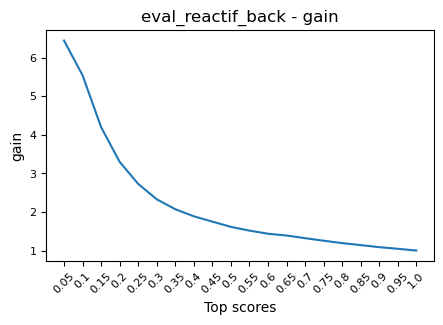

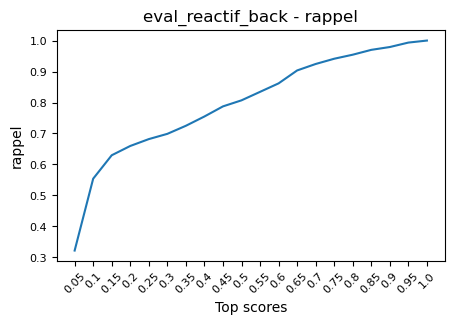

In [20]:
myeval_back_fixe = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters_back,
)

myeval_back_fixe.mobile=False
myeval_back_fixe.sep = sep
myeval_back_fixe.result_suffix = 'back'

myeval_back_fixe.plot(evaluation_back_fixe)

<div style="background-color:PaleGoldenrod; padding:10px 0;">

### *déploiement* : déploiement
   
   période fixe

   production des scores (sur un jour par défaut)

In [21]:
mymodel_depl_fixe = kt.KhiopsClassifier(
    dictionary_depl,
    target_parameters, 
    temporal_parameters_depl,
)

mymodel_depl_fixe.mobile=False
mymodel_depl_fixe.sep = sep
mymodel_depl_fixe.result_suffix = 'depl'

score_by_period_unit_depl_fixe = mymodel_depl_fixe.predict(mydataset_depl)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_depl_sans_target_depl.csv
répertoire : .\notebook\data\synth1\fixe\TransferDatabase_depl --> nombre de déploiements : 1
durée d'exécution : 0:00:05.380401


<div style="background-color:LightSalmon; text-align:center; vertical-align: middle; padding:40px 0;">
    
## Période mobile
</div>

<div style="background-color:PeachPuff; padding:10px 0;">

### target_duration = 15 jours

<div style="background-color:PeachPuff; padding:10px 0;">

### Modélisation

période mobile
    
target_duration = 15 jours

In [22]:
temporal_parameters['target_duration'] = 15
path_suffix15 = str(temporal_parameters['target_duration'])

mymodel_mobile15 = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters,
)

mymodel_mobile15.sep = sep
mymodel_mobile15.path_suffix=path_suffix15
mymodel_mobile15.result_suffix = 'test'

mymodel_mobile15.fit(mydataset_train)

fichier train : .\notebook\data\synth1\sample2_synthetic_ids_train_target15.csv
dictionnaire :.\notebook\data\synth1\sample2_synthetic_dm_ids.kdic
durée d'exécution : 0:00:52.985191


<div style="background-color:PeachPuff; padding:10px 0;">

### *train / test* : déploiement
    
période mobile

target_duration = 15 jours    
    
test par pas de time_unit
    
test sur les mêmes dates que le train

In [23]:
temporal_parameters['target_duration'] = 15
path_suffix15 = str(temporal_parameters['target_duration'])

mymodel_mobile15 = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters,
)

mymodel_mobile15.sep = sep
mymodel_mobile15.path_suffix=path_suffix15
mymodel_mobile15.result_suffix = 'test'

(
    score_by_period_unit_traintest_mobile15, 
    target_by_period_unit_traintest_mobile15,
) = mymodel_mobile15.predict(mydataset_test)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_test.csv
répertoire : .\notebook\data\synth1\mobile15\TransferDatabase_test --> nombre de déploiements : 15
durée d'exécution : 0:00:35.105046


<div style="background-color:PeachPuff; padding:10px 0;">

### *train / test* : évaluation
    
période mobile 
    
target_duration = 15 jours
   
constitution de la table des scores et de la table des cibles par pas de time_unit
    
calcul des indicateurs : précision et rappel

In [24]:
temporal_parameters['target_duration'] = 15

myeval_traintest_mobile15 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters,
)

myeval_traintest_mobile15.sep = sep
myeval_traintest_mobile15.path_suffix = path_suffix15
myeval_traintest_mobile15.result_suffix = 'test'

evaluation_traintest_mobile15 = myeval_traintest_mobile15.evaluate(
    score_by_period_unit_traintest_mobile15, 
    target_by_period_unit_traintest_mobile15,
)

Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile15\eval_reactif_test.xls
Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile15\eval_reactif_test.json


<div style="background-color:PeachPuff; padding:10px 0;">

### *train / test* : représentations graphiques
    
   période mobile
    
   target_duration = 15 jours
    
   courbes par top scores des deux métriques : précision et rappel

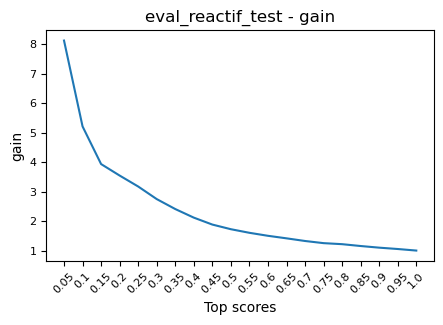

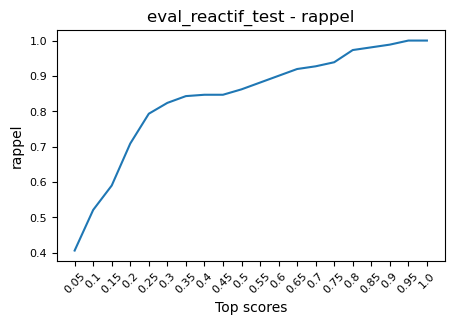

In [25]:
temporal_parameters['target_duration'] = 15

myeval_traintest_mobile15 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters,
)

myeval_traintest_mobile15.sep = sep
myeval_traintest_mobile15.path_suffix = path_suffix15
myeval_traintest_mobile15.result_suffix = 'test'

myeval_traintest_mobile15.plot(evaluation_traintest_mobile15)

<div style="background-color:PeachPuff; padding:10px 0;">

### *backtesting* : déploiement
    
période mobile

target_duration = 15 jours    
    
déploiement par pas de time_unit
    
déploiement avec évaluation sur période postérieure au train / test

In [26]:
temporal_parameters_back['target_duration'] = 15

mymodel_back_mobile15 = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters_back,
)

mymodel_back_mobile15.sep = sep
mymodel_back_mobile15.path_suffix=path_suffix15
mymodel_back_mobile15.result_suffix = "back" 

(
    score_by_period_unit_back_mobile15, 
    target_by_period_unit_back_mobile15,
) = mymodel_back_mobile15.predict(mydataset_back)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_backtesting.csv
répertoire : .\notebook\data\synth1\mobile15\TransferDatabase_back --> nombre de déploiements : 15
durée d'exécution : 0:00:37.124846


<div style="background-color:PeachPuff; padding:10px 0;">

### *backtesting* : évaluation
    
période mobile 
    
target_duration = 15 jours
   
constitution de la table des scores et de la table des cibles par pas de time_unit
    
calcul des indicateurs : précision et rappel

In [27]:
temporal_parameters_back['target_duration'] = 15

myeval_back_mobile15 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters_back,
)

myeval_back_mobile15.sep = sep
myeval_back_mobile15.path_suffix=path_suffix15
myeval_back_mobile15.result_suffix = "back" 

evaluation_back_mobile15 = myeval_back_mobile15.evaluate(
    score_by_period_unit_back_mobile15, 
    target_by_period_unit_back_mobile15,
)

Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile15\eval_reactif_back.xls
Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile15\eval_reactif_back.json


<div style="background-color:PeachPuff; padding:10px 0;">

### *backtesting* : représentations graphiques
    
   période mobile
    
   target_duration = 15 jours
    
   courbes par top scores des deux métriques : précision et rappel

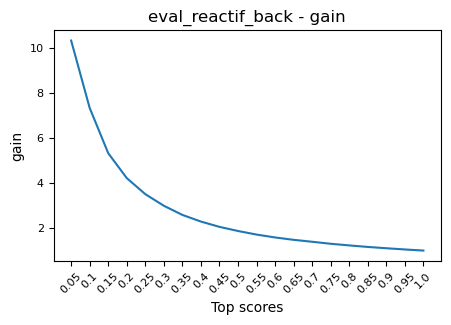

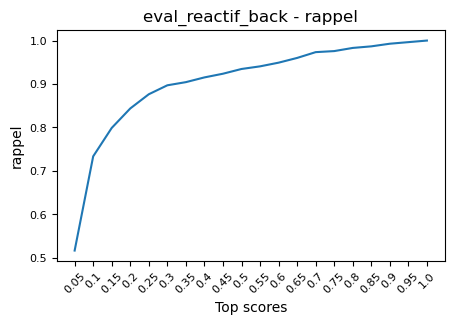

In [28]:
temporal_parameters_back['target_duration'] = 15

myeval_back_mobile15 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters_back,
)

myeval_back_mobile15.sep = sep
myeval_back_mobile15.path_suffix=path_suffix15
myeval_back_mobile15.result_suffix = "back"

myeval_back_mobile15.plot(evaluation_back_mobile15)

<div style="background-color:PeachPuff; padding:10px 0;">

### *déploiement* : déploiement
    
période mobile

target_duration = 15 jours    
    
production des scores (sur un jour par défaut)

In [29]:
temporal_parameters_depl['target_duration'] = 15

mymodel_depl_mobile15 = kt.KhiopsClassifier(
    dictionary_depl,
    target_parameters, 
    temporal_parameters_depl,
)

mymodel_depl_mobile15.sep = sep
mymodel_depl_mobile15.path_suffix=path_suffix15
mymodel_depl_mobile15.result_suffix = 'depl'

score_by_period_unit_depl_mobile15 = mymodel_depl_mobile15.predict(mydataset_depl)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_depl_sans_target_depl.csv
répertoire : .\notebook\data\synth1\mobile15\TransferDatabase_depl --> nombre de déploiements : 1
durée d'exécution : 0:00:05.891096


<div style="background-color:Moccasin; padding:10px 0;">

### target_duration = 7 jours

<div style="background-color:Moccasin; padding:10px 0;">

### Modélisation

période mobile
    
target_duration = 7 jours

In [30]:
temporal_parameters['target_duration'] = 7
temporal_parameters['period_nb'] = 15
path_suffix7 = str(temporal_parameters['target_duration'])

mymodel_mobile7 = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters,
)

mymodel_mobile7.sep = sep
mymodel_mobile7.path_suffix=path_suffix7
mymodel_mobile7.result_suffix = 'test'

mymodel_mobile7.fit(mydataset_train)

fichier train : .\notebook\data\synth1\sample2_synthetic_ids_train_target7.csv
dictionnaire :.\notebook\data\synth1\sample2_synthetic_dm_ids.kdic
durée d'exécution : 0:00:59.598102


<div style="background-color:Moccasin; padding:10px 0;">

### *train / test* : déploiement
    
période mobile

target_duration = 7 jours    
    
test par pas de time_unit
    
test sur les mêmes dates que le train

In [31]:
temporal_parameters['target_duration'] = 7
temporal_parameters['period_nb'] = 15
path_suffix7 = str(temporal_parameters['target_duration'])

mymodel_mobile7 = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters,
)

mymodel_mobile7.sep = sep
mymodel_mobile7.path_suffix=path_suffix7
mymodel_mobile7.result_suffix = 'test'

(
    score_by_period_unit_traintest_mobile7, 
    target_by_period_unit_traintest_mobile7,
) = mymodel_mobile7.predict(mydataset_test)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_test.csv
répertoire : .\notebook\data\synth1\mobile7\TransferDatabase_test --> nombre de déploiements : 15
durée d'exécution : 0:00:35.203053


<div style="background-color:Moccasin; padding:10px 0;">

### *train / test* : évaluation
    
période mobile 
    
target_duration = 7 jours
   
constitution de la table des scores et de la table des cibles par pas de time_unit
    
calcul des indicateurs : précision et rappel

In [32]:
temporal_parameters['target_duration'] = 7
temporal_parameters['period_nb'] = 15

myeval_traintest_mobile7 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters,
)

myeval_traintest_mobile7.sep = sep
myeval_traintest_mobile7.path_suffix = path_suffix7
myeval_traintest_mobile7.result_suffix = 'test'

evaluation_traintest_mobile7 = myeval_traintest_mobile7.evaluate(
    score_by_period_unit_traintest_mobile7, 
    target_by_period_unit_traintest_mobile7,
)

Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile7\eval_reactif_test.xls
Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile7\eval_reactif_test.json


<div style="background-color:Moccasin; padding:10px 0;">

### *train / test* : représentations graphiques
    
   période mobile
    
   target_duration = 7 jours
    
   courbes par top scores des deux métriques : précision et rappel

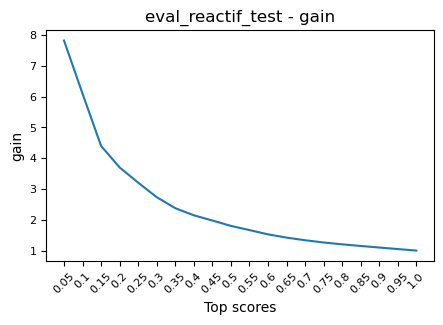

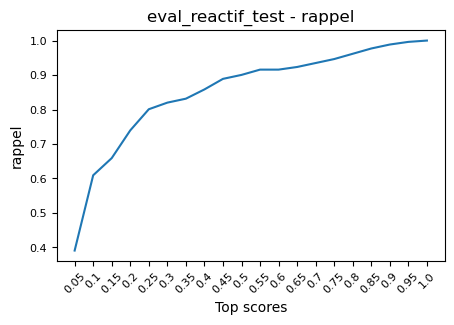

In [33]:
temporal_parameters['target_duration'] = 7
temporal_parameters['period_nb'] = 15

myeval_traintest_mobile7 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters,
)

myeval_traintest_mobile7.sep = sep
myeval_traintest_mobile7.path_suffix = path_suffix7
myeval_traintest_mobile7.result_suffix = 'test'

myeval_traintest_mobile7.plot(evaluation_traintest_mobile7)

<div style="background-color:Moccasin; padding:10px 0;">

### *backtesting* : déploiement
    
période mobile

target_duration = 7 jours    
    
déploiement par pas de time_unit
    
déploiement avec évaluation sur période postérieure au train / test

In [34]:
temporal_parameters_back['target_duration'] = 7
temporal_parameters_back['period_nb'] = 15

mymodel_back_mobile7 = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters_back,
)

mymodel_back_mobile7.sep = sep
mymodel_back_mobile7.path_suffix=path_suffix7
mymodel_back_mobile7.result_suffix = "back" 

(
    score_by_period_unit_back_mobile7, 
    target_by_period_unit_back_mobile7,
) = mymodel_back_mobile7.predict(mydataset_back)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_backtesting.csv
répertoire : .\notebook\data\synth1\mobile7\TransferDatabase_back --> nombre de déploiements : 15
durée d'exécution : 0:00:37.907391


<div style="background-color:Moccasin; padding:10px 0;">

### *backtesting* : évaluation
    
période mobile 
    
target_duration = 7 jours
   
constitution de la table des scores et de la table des cibles par pas de time_unit
    
calcul des indicateurs : précision et rappel

In [35]:
temporal_parameters_back['target_duration'] = 7
temporal_parameters_back['period_nb'] = 15

myeval_back_mobile7 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters_back,
)

myeval_back_mobile7.sep = sep
myeval_back_mobile7.path_suffix=path_suffix7
myeval_back_mobile7.result_suffix = "back" 

evaluation_back_mobile7 = myeval_back_mobile7.evaluate(
    score_by_period_unit_back_mobile7, 
    target_by_period_unit_back_mobile7,
)

Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile7\eval_reactif_back.xls
Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile7\eval_reactif_back.json


<div style="background-color:Moccasin; padding:10px 0;">

### *backtesting* : représentations graphiques
    
   période mobile
    
   target_duration = 7 jours
    
   courbes par top scores des deux métriques : précision et rappel

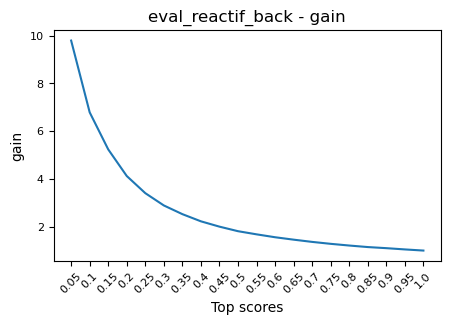

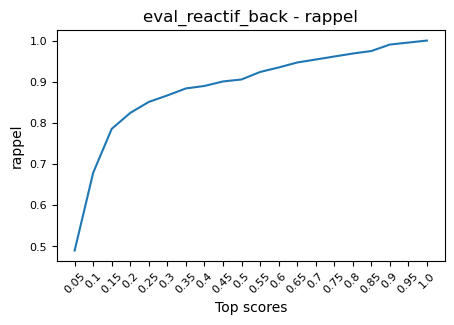

In [36]:
temporal_parameters_back['target_duration'] = 7
temporal_parameters_back['period_nb'] = 15

myeval_back_mobile7 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters_back,
)

myeval_back_mobile7.sep = sep
myeval_back_mobile7.path_suffix=path_suffix7
myeval_back_mobile7.result_suffix = "back" 

myeval_back_mobile7.plot(evaluation_back_mobile7)

<div style="background-color:Moccasin; padding:10px 0;">

### *déploiement* : déploiement
    
période mobile

target_duration = 7 jours    
    
production des scores (sur un jour par défaut)

In [37]:
temporal_parameters_depl['target_duration'] = 7

mymodel_depl_mobile7 = kt.KhiopsClassifier(
    dictionary_depl,
    target_parameters, 
    temporal_parameters_depl,
)

mymodel_depl_mobile7.sep = sep
mymodel_depl_mobile7.path_suffix=path_suffix7
mymodel_depl_mobile7.result_suffix = 'depl'

score_by_period_unit_depl_mobile7 = mymodel_depl_mobile7.predict(mydataset_depl)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_depl_sans_target_depl.csv
répertoire : .\notebook\data\synth1\mobile7\TransferDatabase_depl --> nombre de déploiements : 1
durée d'exécution : 0:00:05.714904


<div style="background-color:PapayaWhip; padding:10px 0;">

### target_duration = 1 jour

<div style="background-color:PapayaWhip; padding:10px 0;">

### Modélisation

période mobile
    
target_duration = 1 jour

In [38]:
temporal_parameters['target_duration'] = 1
path_suffix1 = str(temporal_parameters['target_duration'])

mymodel_mobile1 = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters,
)

mymodel_mobile1.sep = sep
mymodel_mobile1.path_suffix=path_suffix1
mymodel_mobile1.result_suffix = 'test'

mymodel_mobile1.fit(mydataset_train)

fichier train : .\notebook\data\synth1\sample2_synthetic_ids_train_target1.csv
dictionnaire :.\notebook\data\synth1\sample2_synthetic_dm_ids.kdic
durée d'exécution : 0:00:59.284770


<div style="background-color:PapayaWhip; padding:10px 0;">

### *train / test* : déploiement
    
période mobile

target_duration = 1 jour    
    
test par pas de time_unit
    
test sur les mêmes dates que le train

In [39]:
temporal_parameters['target_duration'] = 1
path_suffix1 = str(temporal_parameters['target_duration'])

mymodel_mobile1 = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters,
)

mymodel_mobile1.sep = sep
mymodel_mobile1.path_suffix=path_suffix1
mymodel_mobile1.result_suffix = 'test'

(
    score_by_period_unit_traintest_mobile1, 
    target_by_period_unit_traintest_mobile1,
) = mymodel_mobile1.predict(mydataset_test)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_test.csv
répertoire : .\notebook\data\synth1\mobile1\TransferDatabase_test --> nombre de déploiements : 15
durée d'exécution : 0:00:34.278398


<div style="background-color:PapayaWhip; padding:10px 0;">

### *train / test* : évaluation
    
période mobile 
    
target_duration = 1 jour
   
constitution de la table des scores et de la table des cibles par pas de time_unit
    
calcul des indicateurs : précision et rappel

In [40]:
temporal_parameters['target_duration'] = 1

myeval_traintest_mobile1 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters,
)

myeval_traintest_mobile1.sep = sep
myeval_traintest_mobile1.path_suffix = path_suffix1
myeval_traintest_mobile1.result_suffix = 'test'

evaluation_traintest_mobile1 = myeval_traintest_mobile1.evaluate(
    score_by_period_unit_traintest_mobile1, 
    target_by_period_unit_traintest_mobile1,
)

Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile1\eval_reactif_test.xls
Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile1\eval_reactif_test.json


<div style="background-color:PapayaWhip; padding:10px 0;">

### *train / test* : représentations graphiques
    
   période mobile
    
   target_duration = 1 jour
    
   courbes par top scores des deux métriques : précision et rappel

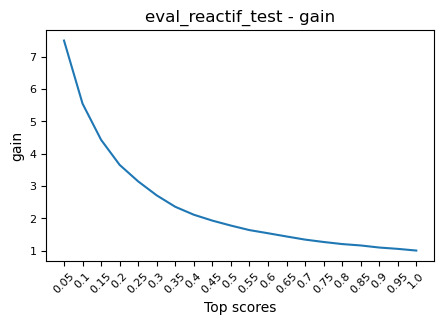

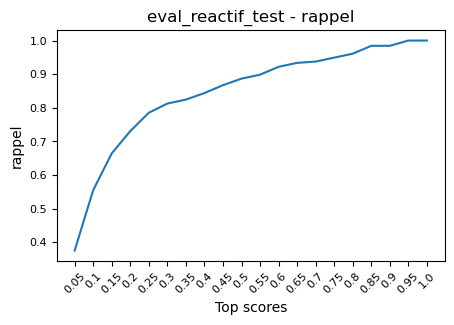

In [41]:
temporal_parameters['target_duration'] = 1

myeval_traintest_mobile1 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters,
)

myeval_traintest_mobile1.sep = sep
myeval_traintest_mobile1.path_suffix = path_suffix1
myeval_traintest_mobile1.result_suffix = 'test'

myeval_traintest_mobile1.plot(evaluation_traintest_mobile1)

<div style="background-color:PapayaWhip; padding:10px 0;">

### *backtesting* : déploiement
    
période mobile

target_duration = 1 jour    
    
déploiement par pas de time_unit
    
déploiement avec évaluation sur période postérieure au train / test

In [42]:
temporal_parameters_back['target_duration'] = 1

mymodel_back_mobile1 = kt.KhiopsClassifier(
    dictionary, 
    target_parameters, 
    temporal_parameters_back,
)

mymodel_back_mobile1.sep = sep
mymodel_back_mobile1.path_suffix=path_suffix1
mymodel_back_mobile1.result_suffix = "back" 

(
    score_by_period_unit_back_mobile1, 
    target_by_period_unit_back_mobile1,
) = mymodel_back_mobile1.predict(mydataset_back)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_backtesting.csv
répertoire : .\notebook\data\synth1\mobile1\TransferDatabase_back --> nombre de déploiements : 15
durée d'exécution : 0:00:36.461799


<div style="background-color:PapayaWhip; padding:10px 0;">

### *backtesting* : évaluation
    
période mobile 
    
target_duration = 1 jour
   
constitution de la table des scores et de la table des cibles par pas de time_unit
    
calcul des indicateurs : précision et rappel

In [43]:
temporal_parameters_back['target_duration'] = 1

myeval_back_mobile1 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters_back,
)

myeval_back_mobile1.sep = sep
myeval_back_mobile1.path_suffix=path_suffix1
myeval_back_mobile1.result_suffix = "back" 

evaluation_back_mobile1 = myeval_back_mobile1.evaluate(
    score_by_period_unit_back_mobile1, 
    target_by_period_unit_back_mobile1,
)

Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile1\eval_reactif_back.xls
Ecriture du fichier de resultats de l evaluation reactif : .\notebook\data\synth1\mobile1\eval_reactif_back.json


<div style="background-color:PapayaWhip; padding:10px 0;">

### *backtesting* : représentations graphiques
    
   période mobile
    
   target_duration = 1 jour
    
   courbes par top scores des deux métriques : précision et rappel

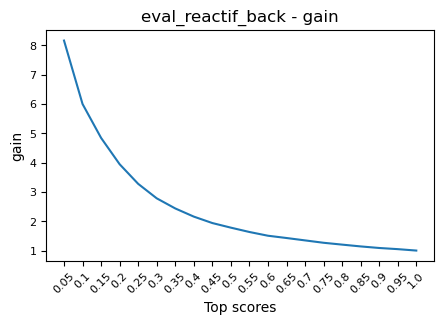

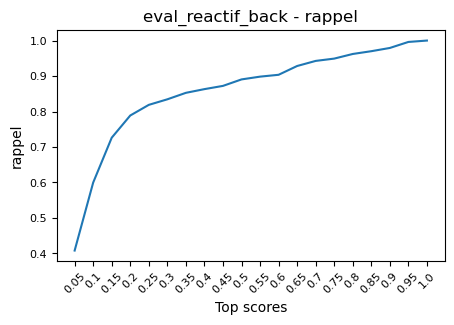

In [45]:
temporal_parameters_back['target_duration'] = 1

myeval_back_mobile1 = kt.TemporalEvaluator(
    data_tables, 
    temporal_parameters_back,
)

myeval_back_mobile1.sep = sep
myeval_back_mobile1.path_suffix=path_suffix1
myeval_back_mobile1.result_suffix = "back"

myeval_back_mobile1.plot(evaluation_back_mobile1)

<div style="background-color:PapayaWhip; padding:10px 0;">

### *déploiement* : déploiement
    
période mobile

target_duration = 1 jour  
    
production des scores (sur un jour par défaut)

In [46]:
temporal_parameters_depl['target_duration'] = 1

mymodel_depl_mobile1 = kt.KhiopsClassifier(
    dictionary_depl,
    target_parameters, 
    temporal_parameters_depl,
)

mymodel_depl_mobile1.sep = sep
mymodel_depl_mobile1.path_suffix=path_suffix1
mymodel_depl_mobile1.result_suffix = 'depl'

score_by_period_unit_depl_mobile1 = mymodel_depl_mobile1.predict(mydataset_depl)

fichier test : .\notebook\data\synth1\sample2_synthetic_ids_depl_sans_target_depl.csv
répertoire : .\notebook\data\synth1\mobile1\TransferDatabase_depl --> nombre de déploiements : 1
durée d'exécution : 0:00:05.705593


<div style="background-color:rgb(155, 55, 128);text-align:center; padding:10px 0; color: white;">
    
## Regroupement sur un même graphique

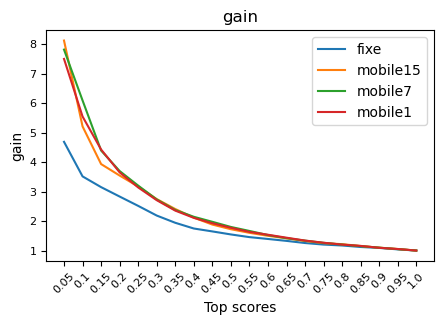

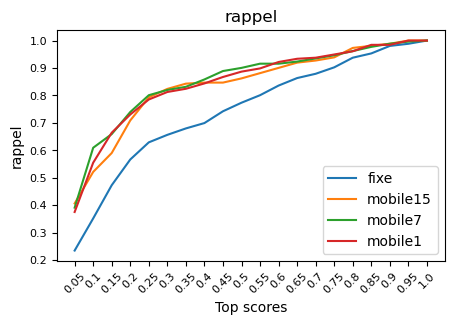

In [47]:
list_path = ['fixe', 'mobile15', 'mobile7', 'mobile1']
myeval_traintest_fixe.plot_all(list_path)

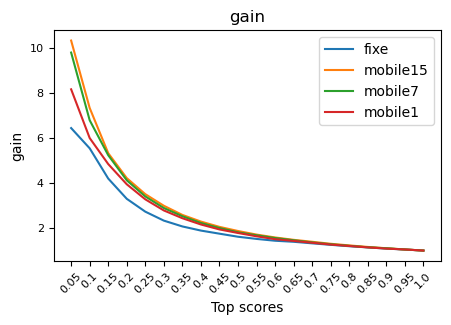

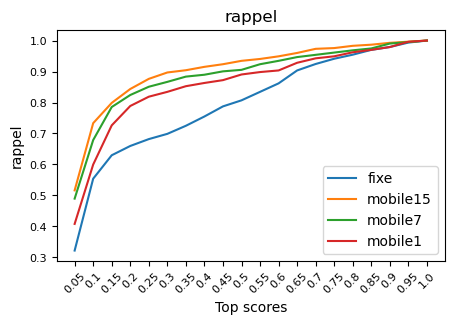

In [48]:
list_path_back = ['fixe','mobile15', 'mobile7', 'mobile1']
myeval_back_fixe.plot_all(list_path_back)

In [7]:
%load_ext autoreload
%autoreload 2

In [64]:
%autoreload 2